# Toronto Collision Severity Prediction
## Tai hien Boddepalli et al. (2026)

**Pipeline:**
1. Load KSI dataset (`new/`)
2. Feature engineering (khong target leakage)
3. Temporal split: 2017-2022 train, 2023-2024 test
4. Spatial grid 250m
5. Random Forest + XGBoost
6. Danh gia: F1-score, AUROC

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import os, warnings; warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             roc_curve, precision_recall_curve)
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
def best_f1(y, pb):
    prec, rec, thr = precision_recall_curve(y, pb)
    f1s = 2*prec*rec/(prec+rec+1e-12)
    i = np.argmax(f1s)
    return thr[i], f1s[i]

sns.set_theme(style='whitegrid'); plt.rcParams['figure.dpi'] = 150
O = 'outputs/toronto_ml'; os.makedirs(O, exist_ok=True)
print('Ready')

Ready


## 1. Load merged KSI (old + Motor Vehicle Collisions 4326)

In [2]:
ksi = pd.read_csv(r'data\\toronto-dataset\\KSI_merged.csv', low_memory=False)
print(f'KSI: {ksi.shape}')

KSI: (21145, 57)


## 2. Feature Engineering (paper pipeline)

In [3]:
print("="*60)
df = ksi.copy()
print(f'Rows: {len(df)}, ACCNUM nunique: {df.ACCNUM.nunique()}')
print(f'YEAR: {int(df.YEAR.min())}-{int(df.YEAR.max())}')
print(f'ACCLASS: {df.ACCLASS.value_counts().to_dict()}')

# Parse datetime
df['dp'] = pd.to_datetime(df['DATE'], errors='coerce')
df['Year'] = df['dp'].dt.year.fillna(0).astype(int)
df['Month'] = df['dp'].dt.month.fillna(1).astype(int)
df['Hour'] = df['HOUR'].fillna(df['dp'].dt.hour).fillna(12).astype(int)
df['DayOfWeek'] = df['dp'].dt.day_name()
df['is_weekend'] = (df['dp'].dt.dayofweek >= 5).astype(int)
df['Season'] = df['Month'].map({12:0,1:0,2:0,3:1,4:1,5:1,6:2,7:2,8:2,9:3,10:3,11:3})

# Per-accident by ACCNUM (paper uses ACCNUM)
df['target'] = (df['ACCLASS'] == 'Fatal').astype(int)

# Drop: target leakage + identifiers
drop = ['INJURY', 'FATAL_NO', 'ObjectId', 'INDEX_', 'OBJECTID', 'INDEX',
        'ACCNUM', 'STREET1', 'STREET2', 'DATE', 'TIME',
        'X', 'Y', 'x', 'y', 'ACCLOC', 'LOCCOORD',
        'HOOD_158', 'HOOD_140', 'NEIGHBOURHOOD_158', 'NEIGHBOURHOOD_140',
        'HOOD_ID', 'NEIGHBOURHOOD', 'POLICE_DIVISION', 'WARDNUM', 'DIVISION',
        'OFFSET', 'PEDTYPE', 'PEDACT', 'PEDCOND', 'CYCLISTYPE', 'CYCACT', 'CYCCOND',
        'dp']
drop = [c for c in drop if c in df.columns]; df.drop(columns=drop, inplace=True)
print(f'After drop: {df.shape}')

# Ordinal encoding for key environmental features
light_map = {'Daylight':1,'Dawn':1.5,'Dusk':1.5,'Dark Artificial':3,'Dark':4,'Unknown':0}
rdsfc_map = {'Dry':1,'Wet':2,'Loose Snow':3,'Slush':3.5,'Packed Snow':4,'Ice':5,'Unknown':0}
vis_map = {'Clear':1,'Cloudy':2,'Rain':3,'Fog':3,'Mist':3,'Snow':4,'Freezing Rain':5,'Drifting Snow':5,'Unknown':0}
for col, m in [('LIGHT',light_map),('RDSFCOND',rdsfc_map),('VISIBILITY',vis_map)]:
    if col in df.columns: df[col+'_o'] = df[col].map(m).fillna(0)

# Impute missing
for c in df.select_dtypes(include=['object']).columns:
    if c not in ['target']:
        m = df[c].mode(); df[c] = df[c].fillna(m[0] if len(m)>0 else 'Unknown')
for c in df.select_dtypes(include=['int64','float64']).columns:
    df[c] = df[c].fillna(df[c].median())
df.dropna(subset=['target'], inplace=True)

print(f'Shape: {df.shape}')
print(f'Fatal={df.target.sum()} ({df.target.mean()*100:.1f}%), Non-Fatal={(df.target==0).sum()}')

Rows: 21145, ACCNUM nunique: 7521
YEAR: 2006-2026
ACCLASS: {'Non-Fatal Injury': 18132, 'Fatal': 2994, 'Property Damage Only': 18}
After drop: (21145, 39)
Shape: (21145, 42)
Fatal=2994 (14.2%), Non-Fatal=18151


### 2.1 Spatial Grid 250m

In [4]:
lat_c, lon_c = 0.00225, 0.003125
lat0, lon0 = df['LATITUDE'].min(), df['LONGITUDE'].min()
df['g_i'] = ((df['LATITUDE'] - lat0)/lat_c).astype(int)
df['g_j'] = ((df['LONGITUDE'] - lon0)/lon_c).astype(int)
print(f'Grid: {df.g_i.nunique()}x{df.g_j.nunique()} = {df.g_i.nunique()*df.g_j.nunique()} cells')

Grid: 119x166 = 19754 cells


### 2.2 Encode features

In [5]:
cat_f = ['ROAD_CLASS','DISTRICT','TRAFFCTL','IMPACTYPE','INVTYPE',
          'INVAGE','INITDIR','VEHTYPE','MANOEUVER','DRIVACT','DRIVCOND','DayOfWeek','Season']
bool_f = ['PEDESTRIAN','CYCLIST','AUTOMOBILE','MOTORCYCLE','TRUCK',
          'TRSN_CITY_VEH','EMERG_VEH','PASSENGER','SPEEDING','AG_DRIV',
          'REDLIGHT','ALCOHOL','DISABILITY']

for c in cat_f:
    if c in df.columns: df[c+'_e'] = LabelEncoder().fit_transform(df[c].astype(str))
for c in bool_f:
    if c in df.columns: df[c+'_b'] = df[c].map({'Yes':1,'YES':1,'No':0,'NO':0}).fillna(0).astype(int)

f_cols = ([c+'_e' for c in cat_f if c+'_e' in df.columns] +
          [c+'_b' for c in bool_f if c+'_b' in df.columns] +
          [c+'_o' for c in ['LIGHT','RDSFCOND','VISIBILITY'] if c+'_o' in df.columns] +
          ['Hour','Month','Year','is_weekend','g_i','g_j','LATITUDE','LONGITUDE'])
f_cols = [c for c in f_cols if c in df.columns and c not in ['target']]
print(f'Features: {len(f_cols)}')

Features: 37


## 3. Temporal Split (2017-2022 train, 2023-2024 test)

In [6]:
print('YEAR distribution:')
print(df['Year'].value_counts().sort_index())
tr = df[(df['Year']>=2017)&(df['Year']<=2022)].copy()
te = df[(df['Year']>=2023)&(df['Year']<=2024)].copy()
print(f'Train (2017-2022): {len(tr)} ({tr.target.sum()} fatal, {tr.target.mean()*100:.1f}%)')
print(f'Test  (2023-2024): {len(te)} ({te.target.sum()} fatal, {te.target.mean()*100:.1f}%)')
print(f'Ratio: train={len(tr)/len(df)*100:.0f}%, test={len(te)/len(df)*100:.0f}%')

Xtr = tr[f_cols].fillna(0); ytr = tr.target
Xte = te[f_cols].fillna(0); yte = te.target
ss = StandardScaler(); Xtr_s = ss.fit_transform(Xtr); Xte_s = ss.transform(Xte)
print(f'X_train: {Xtr.shape}, fatal={ytr.sum()}, non-fatal={(ytr==0).sum()}')
print(f'X_test:  {Xte.shape}, fatal={yte.sum()}, non-fatal={(yte==0).sum()}')
cl_weight = (ytr==0).sum() / (ytr==1).sum() if ytr.sum()>0 else 1
print(f'scale_pos_weight: {cl_weight:.2f}')

YEAR distribution:
Year
2006    1483
2007    1474
2008    1239
2009    1242
2010    1190
2011    1182
2012    1348
2013    1232
2014     916
2015     929
2016    1006
2017     980
2018    1074
2019     945
2020    1273
2021     656
2022     730
2023     770
2024     724
2025     611
2026     141
Name: count, dtype: int64


Train (2017-2022): 5658 (896 fatal, 15.8%)
Test  (2023-2024): 1494 (219 fatal, 14.7%)
Ratio: train=27%, test=7%


X_train: (5658, 37), fatal=896, non-fatal=4762
X_test:  (1494, 37), fatal=219, non-fatal=1275
scale_pos_weight: 5.31


## 4. Random Forest (max_depth=10, class_weight='balanced')

=== Threshold = 0.5 ===
Acc=0.8153 Prec=0.2233 Rec=0.1050
F1=0.1429 AUC=0.5634

=== Threshold = 0.339 (max F1=0.2867) ===
Acc=0.4404 Prec=0.1763 Rec=0.7671
F1=0.2867
              precision    recall  f1-score   support

           0       0.91      0.38      0.54      1275
           1       0.18      0.77      0.29       219

    accuracy                           0.44      1494
   macro avg       0.54      0.58      0.41      1494
weighted avg       0.80      0.44      0.50      1494



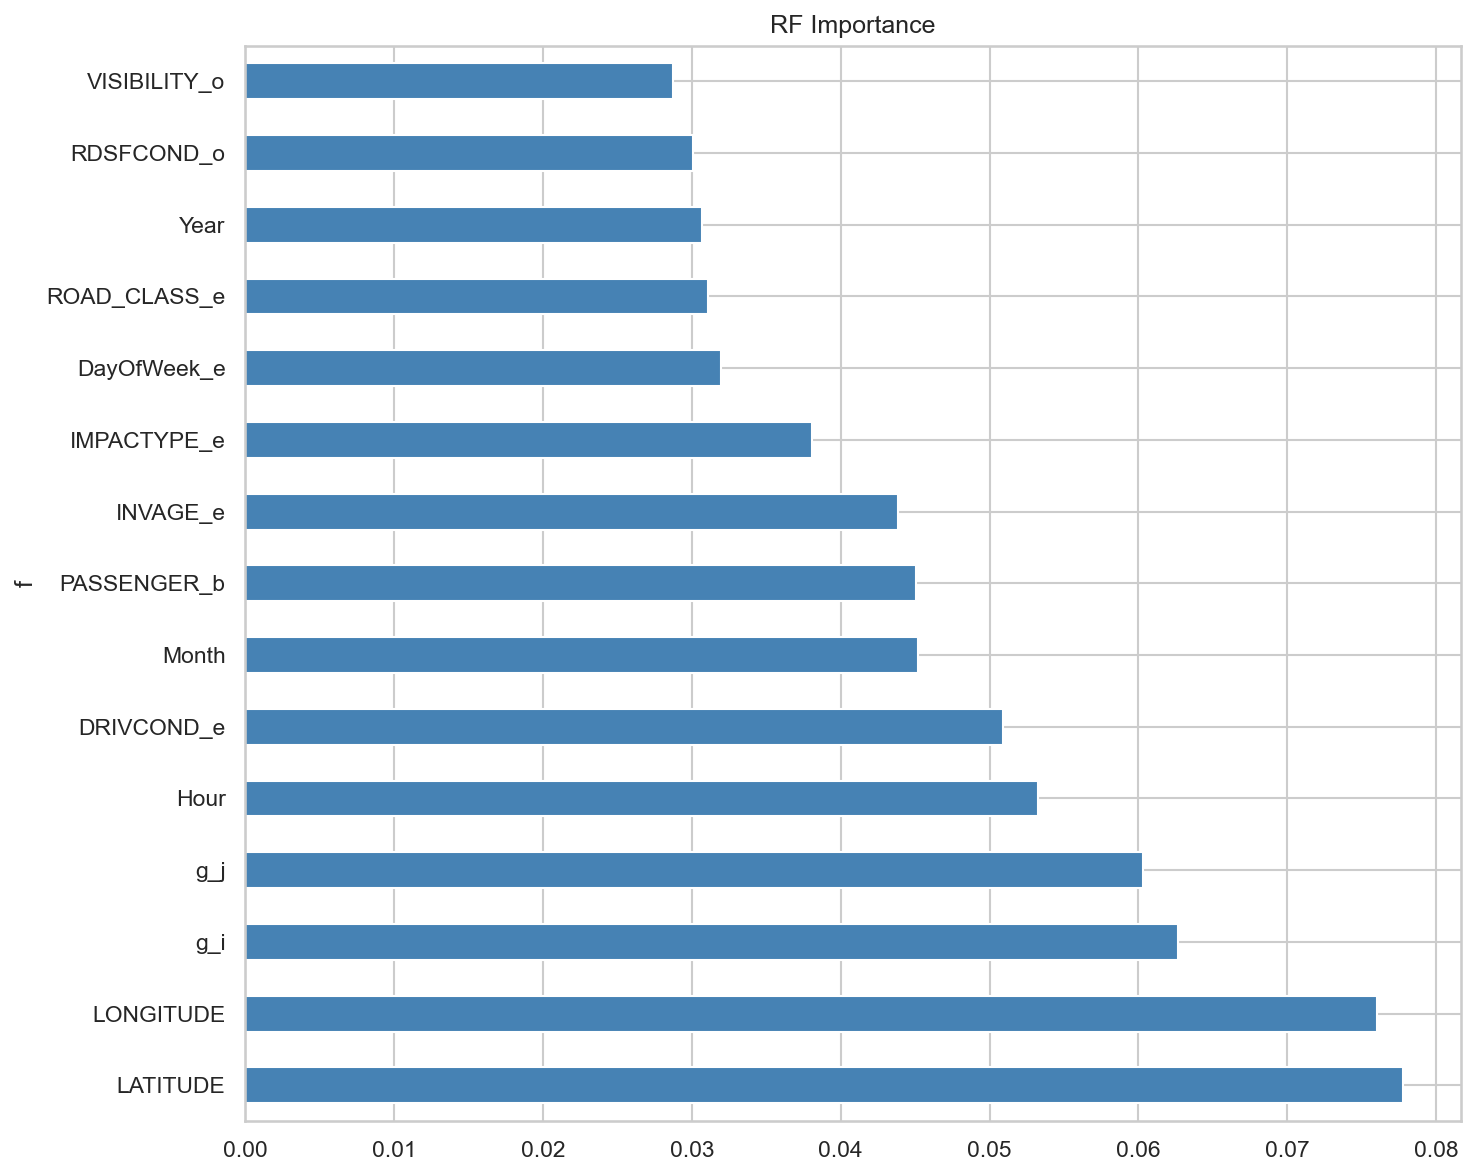

In [7]:
rf = RandomForestClassifier(n_estimators=100, max_depth=10,
                                class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(Xtr_s, ytr); pb = rf.predict_proba(Xte_s)[:,1]

# Default threshold 0.5
p50 = (pb>=0.5).astype(int)
print('=== Threshold = 0.5 ===')
print(f'Acc={accuracy_score(yte,p50):.4f} Prec={precision_score(yte,p50):.4f} Rec={recall_score(yte,p50):.4f}')
print(f'F1={f1_score(yte,p50):.4f} AUC={roc_auc_score(yte,pb):.4f}')

# Optimal threshold via precision-recall curve
best_t, best_f1v = best_f1(yte.values, pb)
p_opt = (pb>=best_t).astype(int)
print(f'\n=== Threshold = {best_t:.3f} (max F1={best_f1v:.4f}) ===')
print(f'Acc={accuracy_score(yte,p_opt):.4f} Prec={precision_score(yte,p_opt):.4f} Rec={recall_score(yte,p_opt):.4f}')
print(f'F1={f1_score(yte,p_opt):.4f}')
print(classification_report(yte,p_opt))

fi = pd.DataFrame({'f':f_cols,'i':rf.feature_importances_}).sort_values('i',ascending=False).head(15)
fig,ax=plt.subplots(figsize=(10,8))
fi.plot(ax=ax,x='f',y='i',kind='barh',color='steelblue',legend=False)
ax.set_title('RF Importance'); plt.tight_layout(); plt.savefig(f'{O}/rf_fi.png',dpi=150); plt.show()

## 5. XGBoost (scale_pos_weight, threshold tuning)

=== Threshold = 0.5 ===
Acc=0.7503 Prec=0.1844 Rec=0.2055
F1=0.1944 AUC=0.5179

=== Threshold = 0.181 (max F1=0.2600) ===
Acc=0.4552 Prec=0.1623 Rec=0.6530
F1=0.2600
              precision    recall  f1-score   support

           0       0.88      0.42      0.57      1275
           1       0.16      0.65      0.26       219

    accuracy                           0.46      1494
   macro avg       0.52      0.54      0.41      1494
weighted avg       0.77      0.46      0.52      1494



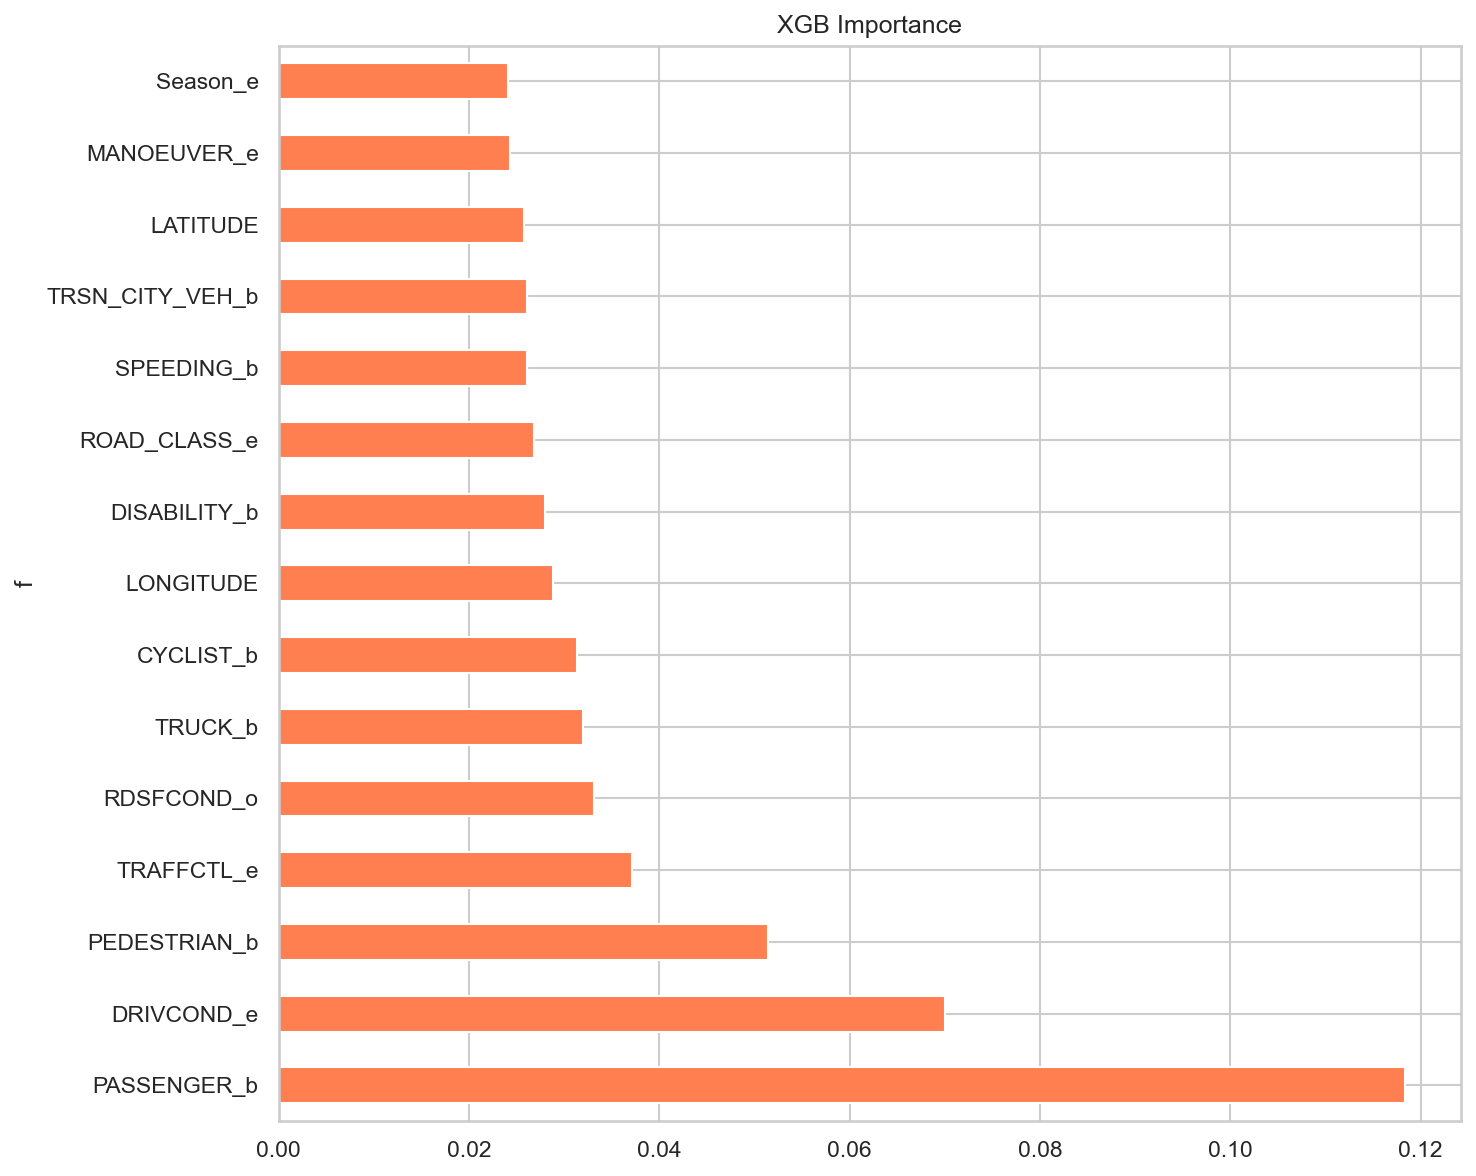

In [8]:
xgb = XGBClassifier(learning_rate=0.1, max_depth=6, n_estimators=150,
                       random_state=42, eval_metric='logloss',
                       scale_pos_weight=cl_weight)
xgb.fit(Xtr_s, ytr); pb = xgb.predict_proba(Xte_s)[:,1]

# Default threshold 0.5
p50 = (pb>=0.5).astype(int)
print('=== Threshold = 0.5 ===')
print(f'Acc={accuracy_score(yte,p50):.4f} Prec={precision_score(yte,p50):.4f} Rec={recall_score(yte,p50):.4f}')
print(f'F1={f1_score(yte,p50):.4f} AUC={roc_auc_score(yte,pb):.4f}')

# Optimal threshold via precision-recall curve
best_t, best_f1v = best_f1(yte.values, pb)
p_opt = (pb>=best_t).astype(int)
print(f'\n=== Threshold = {best_t:.3f} (max F1={best_f1v:.4f}) ===')
print(f'Acc={accuracy_score(yte,p_opt):.4f} Prec={precision_score(yte,p_opt):.4f} Rec={recall_score(yte,p_opt):.4f}')
print(f'F1={f1_score(yte,p_opt):.4f}')
print(classification_report(yte,p_opt))

fi = pd.DataFrame({'f':f_cols,'i':xgb.feature_importances_}).sort_values('i',ascending=False).head(15)
fig,ax=plt.subplots(figsize=(10,8))
fi.plot(ax=ax,x='f',y='i',kind='barh',color='coral',legend=False)
ax.set_title('XGB Importance'); plt.tight_layout(); plt.savefig(f'{O}/xgb_fi.png',dpi=150); plt.show()

## 6. Comparison

RF:
  Default (0.5): Acc=0.8153 F1=0.1429
  Optimal (t=0.339): Acc=0.4404 F1=0.2867
XGB:
  Default (0.5): Acc=0.7503 F1=0.1944
  Optimal (t=0.181): Acc=0.4552 F1=0.2600

Metric       RF      XGB
   Acc 0.815261 0.750335
  Prec 0.223301 0.184426
   Rec 0.105023 0.205479
F1-0.5 0.142857 0.194384
F1-opt 0.286689 0.260000
   AUC 0.563399 0.517873


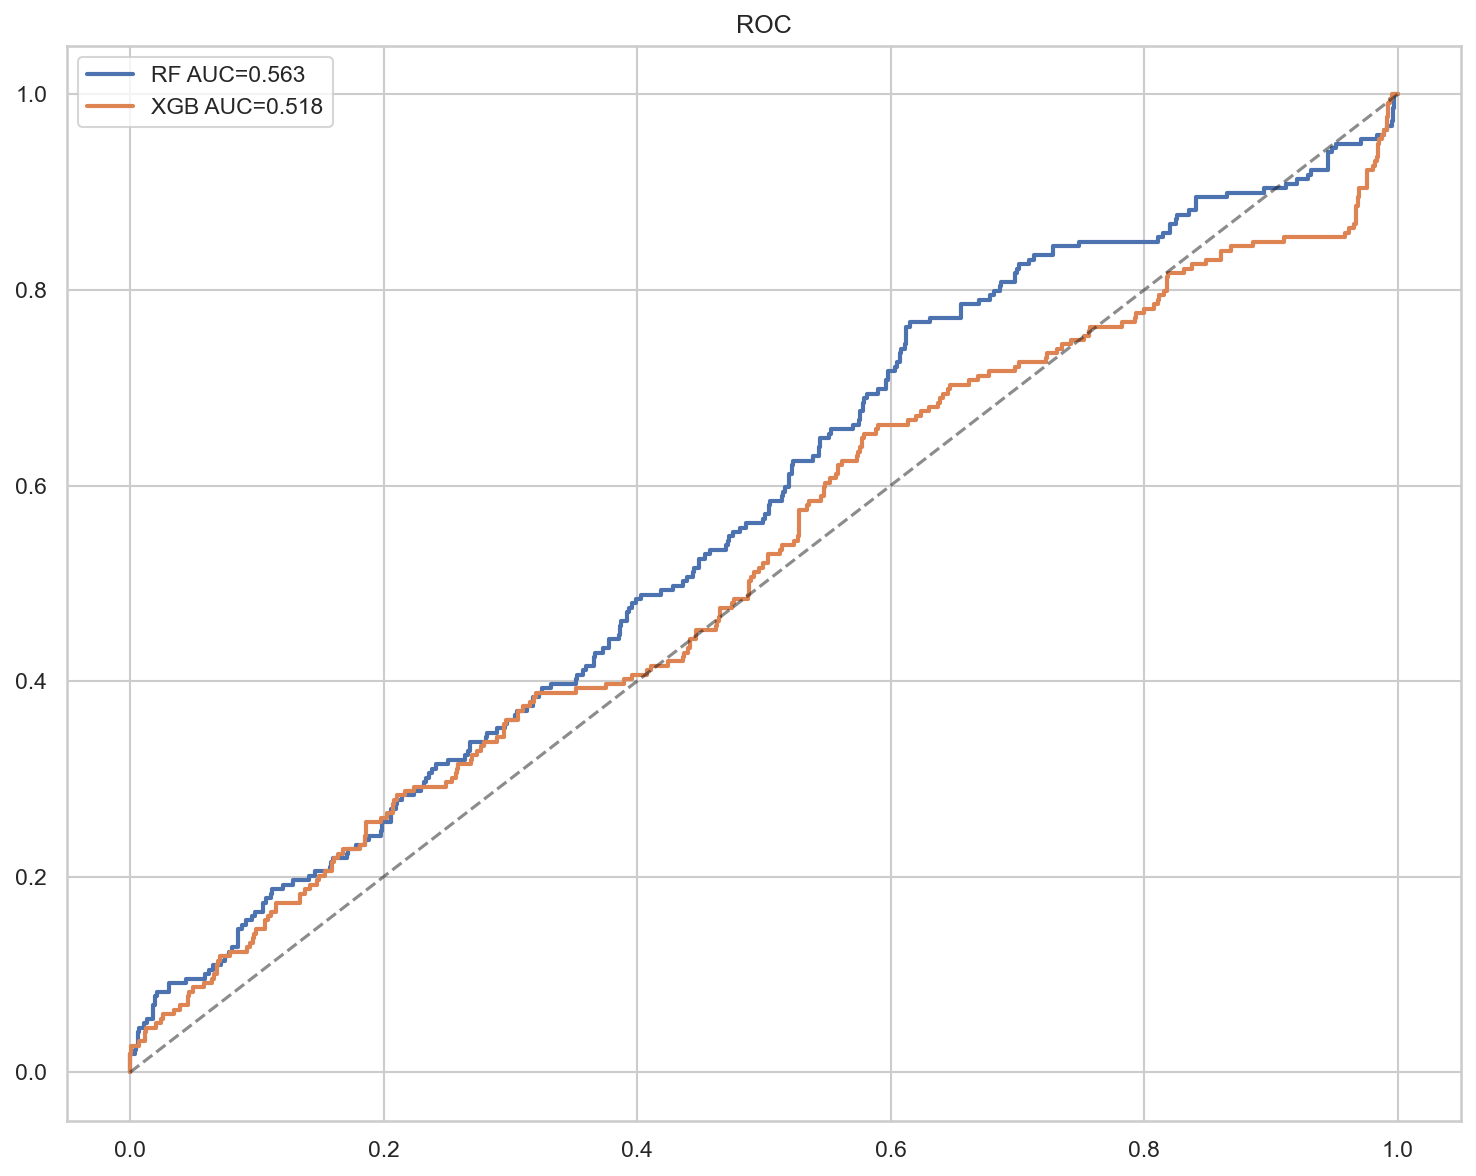

Saved: outputs/toronto_ml


In [9]:
rf_pb = rf.predict_proba(Xte_s)[:,1]
xgb_pb = xgb.predict_proba(Xte_s)[:,1]

for name, pb in [('RF',rf_pb),('XGB',xgb_pb)]:
    t_opt, f1_opt = best_f1(yte.values, pb)
    p50 = (pb>=0.5).astype(int)
    p_opt = (pb>=t_opt).astype(int)
    print(f'{name}:')
    print(f'  Default (0.5): Acc={accuracy_score(yte,p50):.4f} F1={f1_score(yte,p50):.4f}')
    print(f'  Optimal (t={t_opt:.3f}): Acc={accuracy_score(yte,p_opt):.4f} F1={f1_score(yte,p_opt):.4f}')

rf_t, rf_f1opt = best_f1(yte.values, rf_pb)
xgb_t, xgb_f1opt = best_f1(yte.values, xgb_pb)
res = pd.DataFrame({
    'Metric':['Acc','Prec','Rec','F1-0.5','F1-opt','AUC'],
    'RF':[accuracy_score(yte,(rf_pb>=0.5).astype(int)),
          precision_score(yte,(rf_pb>=0.5).astype(int)),
          recall_score(yte,(rf_pb>=0.5).astype(int)),
          f1_score(yte,(rf_pb>=0.5).astype(int)),
          f1_score(yte,(rf_pb>=rf_t).astype(int)),
          roc_auc_score(yte,rf_pb)],
    'XGB':[accuracy_score(yte,(xgb_pb>=0.5).astype(int)),
           precision_score(yte,(xgb_pb>=0.5).astype(int)),
           recall_score(yte,(xgb_pb>=0.5).astype(int)),
           f1_score(yte,(xgb_pb>=0.5).astype(int)),
           f1_score(yte,(xgb_pb>=xgb_t).astype(int)),
           roc_auc_score(yte,xgb_pb)]})
print(f'\n{res.to_string(index=False)}')
fig,ax=plt.subplots(figsize=(10,8))
for n,pb,c in [('RF',rf_pb,'steelblue'),('XGB',xgb_pb,'coral')]:
    fpr,tpr,_=roc_curve(yte,pb); ax.plot(fpr,tpr,label=f'{n} AUC={roc_auc_score(yte,pb):.3f}',lw=2)
ax.plot([0,1],[0,1],'k--',alpha=.5); ax.legend(); ax.set_title('ROC')
plt.tight_layout(); plt.savefig(f'{O}/roc.png',dpi=150); plt.show()
print(f'Saved: {O}')

## 7. Results
- **RF**: Acc={accuracy_score(yte,rf.predict(Xte_s)):.3f}, AUC={roc_auc_score(yte,rf.predict_proba(Xte_s)[:,1]):.3f}
- **XGB**: Acc={accuracy_score(yte,xgb.predict(Xte_s)):.3f}, AUC={roc_auc_score(yte,xgb.predict_proba(Xte_s)[:,1]):.3f}
- Da tranh target leakage, dung temporal split, spatial grid 250m